In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA

df = pd.read_excel("ppp_bank_data_cleaned.xlsx")

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8943 entries, 0 to 8942
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   cust_id                           8943 non-null   str    
 1   balance                           8943 non-null   float64
 2   balance_frequency                 8943 non-null   float64
 3   purchases                         8943 non-null   float64
 4   oneoff_purchases                  8943 non-null   float64
 5   installments_purchases            8943 non-null   float64
 6   cash_advance                      8943 non-null   float64
 7   purchases_frequency               8943 non-null   float64
 8   oneoff_purchases_frequency        8943 non-null   float64
 9   purchases_installments_frequency  8943 non-null   float64
 10  cash_advance_frequency            8943 non-null   float64
 11  cash_advance_trx                  8943 non-null   int64  
 12  purchases_trx    

In [19]:
features = [
    "balance_frequency",
    "purchases_frequency",
    "purchases_trx",
    "purchases",
    "cash_advance_trx"
]
X = df[features]

In [20]:
# Scale data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(X)

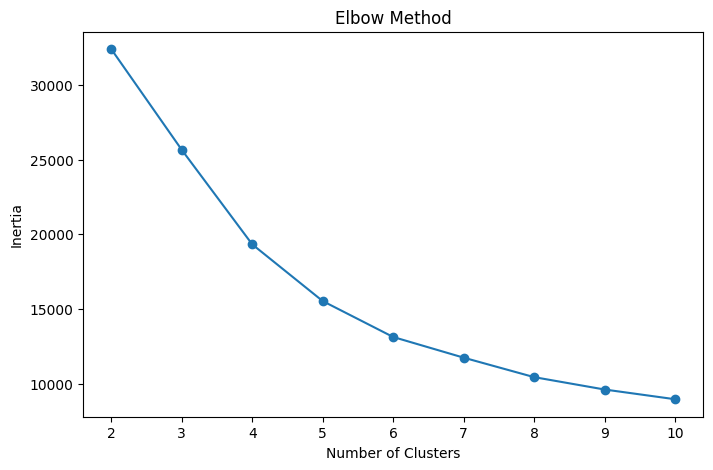

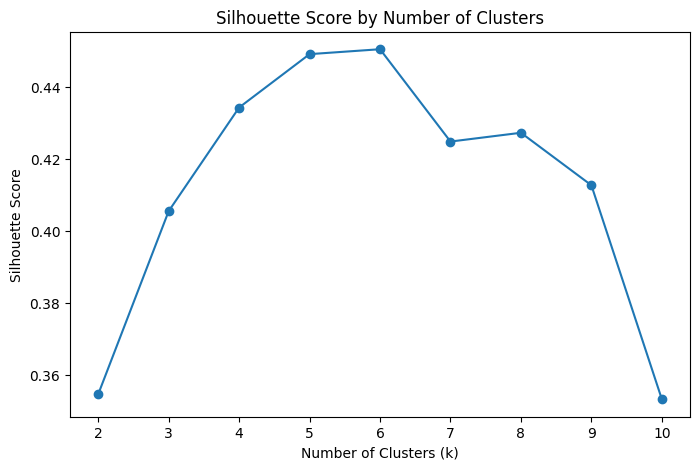

Clusters: 2, Silhouette Score: 0.3547
Clusters: 3, Silhouette Score: 0.4056
Clusters: 4, Silhouette Score: 0.4344
Clusters: 5, Silhouette Score: 0.4492
Clusters: 6, Silhouette Score: 0.4506
Clusters: 7, Silhouette Score: 0.4249
Clusters: 8, Silhouette Score: 0.4274
Clusters: 9, Silhouette Score: 0.4128
Clusters: 10, Silhouette Score: 0.3533

Selected number of clusters: 6


In [21]:
# Find optimal number of clusters
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(scaled_data)
    
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(scaled_data, labels))

# Elbow plot
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

# Silhouette plot
plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker="o")
plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.show()

# Print silhouette scores
for k, score in zip(K_range, silhouette_scores):
    print(f"Clusters: {k}, Silhouette Score: {score:.4f}")

best_k = K_range[silhouette_scores.index(max(silhouette_scores))]
print(f"\nSelected number of clusters: {best_k}")


In [22]:
#Although k=6 gave the highest silhouette score, k=4 (or 5) was selected for better interpretability.
# Final model (k = 4 for interpretability)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(scaled_data)

In [23]:
cluster_analysis = df.groupby("Cluster")[features].mean()
print(cluster_analysis)


         balance_frequency  purchases_frequency  purchases_trx    purchases  \
Cluster                                                                       
0                 0.967604             0.862123      21.704497  1315.585621   
1                 0.384382             0.281183       4.439232   354.919964   
2                 0.989324             0.961209     100.457766  7795.153215   
3                 0.969516             0.121815       2.169240   204.682668   

         cash_advance_trx  
Cluster                    
0                1.580567  
1                0.911158  
2                2.855586  
3                6.067288  


In [ ]:
df.groupby("Cluster")[features].mean() 

,balance_frequency,purchases_frequency,purchases_trx,purchases,cash_advance_trx
Cluster,,,,,
0,0.967604,0.862123,21.704497,1315.585621,1.580567
1,0.384382,0.281183,4.439232,354.919964,0.911158
2,0.989324,0.961209,100.457766,7795.153215,2.855586
3,0.969516,0.121815,2.169240,204.682668,6.067288


In [25]:
df["Cluster"].value_counts()

Cluster
0    3736
3    3433
1    1407
2     367
Name: count, dtype: int64

#### The clustering results reveal clear differences in customer behaviour and engagement.

Power Users represent the most active segment, with exceptionally high purchase frequency, transaction counts, and total spending. Although this group is relatively small, their activity level is significantly higher than all other segments, which justifies treating them as a separate cluster. These customers are highly valuable and central to the business.

Everyday Users consist of regularly active customers who use the service consistently, but at a lower intensity compared to Power Users. They represent a stable and important segment with predictable usage patterns.

Ghost Mode customers show low engagement across all variables, with few transactions, low purchase frequency, and minimal overall activity. These customers appear to have the product but rarely use it.

Cash Advance Focused customers are characterized by low purchasing activity but a high number of cash advance transactions, indicating a reliance on credit rather than regular spending behaviour. This group may represent higher financial risk and a different usage pattern compared to other segments.

Overall, the clusters represent distinct levels and types of customer engagement, ranging from highly active and valuable users to passive and credit-reliant customers.

In [26]:
# Namning clusters
cluster_names = {
    0: "Everyday Users",
    1: "Ghost Mode",
    2: "Power Users",
    3: "Cash-Advance Focused"
}

df["Segment_Name"] = df["Cluster"].map(cluster_names)


In [27]:
# PCA visualization
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_data)

df["PCA1"] = pca_components[:, 0]
df["PCA2"] = pca_components[:, 1]

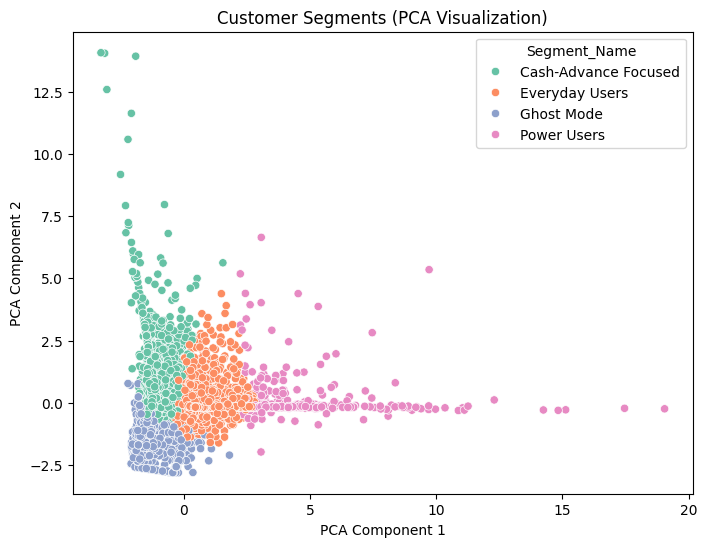

In [28]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x="PCA1",
    y="PCA2",
    hue="Segment_Name",
    data=df,
    palette="Set2"
)

plt.title("Customer Segments (PCA Visualization)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.show()

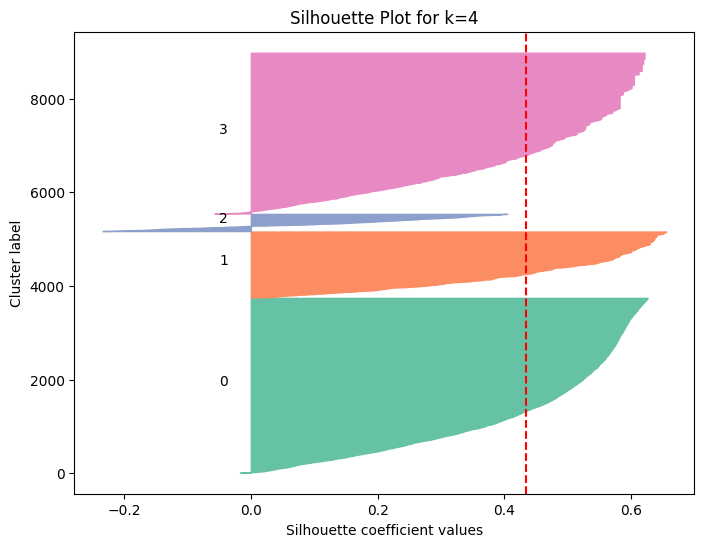

In [29]:
# Silhouette plot per cluster (cluster quality and separation)
sample_silhouette_values = silhouette_samples(scaled_data, df["Cluster"])

y_lower = 10
n_clusters = 4

colors = sns.color_palette("Set2", n_clusters)

plt.figure(figsize=(8, 6))

for i in range(n_clusters):
    cluster_silhouette_values = sample_silhouette_values[df["Cluster"] == i]
    
    cluster_silhouette_values.sort()
    
    size_cluster_i = cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i
    
    plt.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        cluster_silhouette_values,
        color=colors[i]
    )
    
    
    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    
    y_lower = y_upper + 10

plt.axvline(x=np.mean(sample_silhouette_values), color="red", linestyle="--")

plt.title("Silhouette Plot for k=4")
plt.xlabel("Silhouette coefficient values")
plt.ylabel("Cluster label")

plt.show()

In [30]:
df.to_csv("ppp_final_bank_data_with_clusters_renamed.csv", index=False)

In [31]:
df.to_excel("ppp_final_bank_data_with_clusters_renamed.xlsx", index=False)